In [2]:
from dotenv import load_dotenv
import os
load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [1]:
from langchain_groq.chat_models import ChatGroq
from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict,Optional
from langchain_core.messages import AIMessage
from langgraph.prebuilt import ToolNode
from langchain_core.prompts import ChatPromptTemplate
import operator
from langchain_tavily import TavilySearch

In [41]:
tools = [TavilySearch(api_key=TAVILY_API_KEY, max_results=3)]

In [42]:
tool_node = ToolNode(tools=tools)

In [43]:
class WorkerState(TypedDict):
    question: str
    messages: Annotated[list, operator.add]
    correction: AIMessage
    score: float
    counter: int

In [3]:
llm = ChatGroq(model="openai/gpt-oss-20b", api_key=GROQ_API_KEY)

In [ ]:
prompt = ChatPromptTemplate.from_template("""
    You are *The Decomposer*, a highly intelligent query decomposer.

    ### PRIMARY GOAL
    - Given a user question you should carefully and robustly analyze it in order to decompose a query into a set of instructions.
    - These instructions should be concrete and short, they will serve as additional clues for another researcher agent.

    ### INPUT CONTEXT
    - User question: {question}

    ### OUPUT Format
    - A set of instructions following which another llm will be able to fully answer user question

    ### EXAMPLE OF DECOMPOSIOTION
    Say, we have the following query: 'I want to buy a car. My budget is $20000 but I can not decide myself. I want it to be sedan with 2.0 diesel engine. It should be relised
    at least in 2020. I do not want to buy Peugeot, Citroen or VolksWagen.' Then the decomposition is the following:
    - User wants to buy a car
    - User budget is $20000
    - Car should be sedan
    - Car should have 2.0 diesel engine
    - Car should not be older than 2020
    - Car should not be Peugeot, Citroen or VolksWagen
    """)

In [9]:
from pydantic import BaseModel, Field
class DecomposerResponse(BaseModel):
    instructions: list

In [12]:
chain = prompt | llm.with_structured_output(DecomposerResponse, method="json_schema")

In [17]:
response = chain.invoke({
    "question": "I'm planning a vacation trip to Europe and my budget is $5000. I've already been to France, Germany and Bulgaria and want something new. Could you help me decide where to go as well as provide why"
})

In [18]:
response.instructions

["Identify user's travel preferences: new European destinations, budget $5000, excluding France, Germany, Bulgaria.",
 'Generate a shortlist of 3–5 countries that fit the budget and are not previously visited.',
 'For each shortlisted country, calculate an approximate total cost per person (flight, accommodation, daily expenses).',
 'Provide key attractions and unique selling points for each country to justify the recommendation.',
 'Suggest the optimal travel season based on cost and weather.',
 'Include a brief comparison table summarizing cost, attractions, and travel time for quick decision-making.']

In [45]:
persona_prompt = ChatPromptTemplate.from_template("""
You are an intelligent decision making helper. Your primary goal is to help user make a good decision on their question.
The question is: {question}
Do not repeat yourself. To help you with this you are given a full history of your own messages: {messages}
You work in pair with a reflector, they are here to check your answer and rate it with possible corrections. Apply these corrections to enhance your next answer: {corrections}

IMPORTANT: When using tools, only provide the 'query' parameter. Do not include any other parameters like search_depth, topic, etc.
""")

In [46]:
reflector_prompt = ChatPromptTemplate.from_template("""
You are an intelligent decision making helper. Your primary goal is to check the answer of another agent and rate it from 1 to 10.
Along with rating you are to analyze the reply and compare it against the user question. If you decide that something is missing or could be written better
you are to provide this corrections(only instructions what another llm should correct)
The user question is: {question}
The llm response to be reviewed is: {message}""")

In [47]:
def persona_call(state:WorkerState):
    chain = persona_prompt | llm.bind_tools(tools)
    question = state["question"]
    messages = state["messages"]
    correction = state["correction"]
    response = chain.invoke({
        "question": question,
        "messages": messages,
        "corrections": correction
    })
    return {"messages": [response]}

In [48]:
def should_use_tools(state:WorkerState):
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return "reflection_call"

In [49]:
from pydantic import BaseModel, Field

class ReflectionResponse(BaseModel):
    score: float = Field(default=0, description="A message score against provided question")
    correction: str = Field(..., description="Instructions for corrections")

In [50]:
def reflection_call(state:WorkerState):
    chain = reflector_prompt | llm.with_structured_output(ReflectionResponse, method="json_schema")
    question = state["question"]
    messages = state["messages"]
    last_message = messages[-1]
    counter = state["counter"]
    response = chain.invoke({
        "question": question,
        "message": last_message
    })
    counter += 1
    return{
        "score": response.score,
        "correction": response.correction,
        "counter": counter
    }

In [51]:
def should_end(state:WorkerState):
    counter = state["counter"]
    score = state["score"]
    if counter >= 3:
        return "END"
    if score >= 7.0:
        return "END"
    return "persona_call"

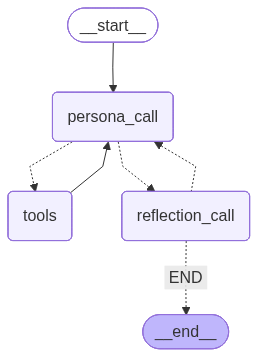

In [52]:
graph = StateGraph(WorkerState)

graph.add_node("persona_call", persona_call)
graph.add_node("tools", tool_node)
graph.add_node("reflection_call", reflection_call)
graph.add_edge(START, "persona_call")
graph.add_conditional_edges(
    source="persona_call",
    path=should_use_tools,
    path_map={
        "tools": "tools",
        "reflection_call": "reflection_call"
    }
)
graph.add_edge("tools", "persona_call")
graph.add_conditional_edges(
    source="reflection_call",
    path=should_end,
    path_map={
        "persona_call": "persona_call",
        "END": END
    }
)
app = graph.compile()
app

In [53]:
initial_state = {
    "question": "I'm planning to have a vacation but don't know where to fly. Currently I'm choosing betweem Bali and Paris. Could you please help me decide.",
    "messages": [],
    "correction": "",
    "counter": 0,
    "score": 0.0
}

In [54]:
response = app.invoke(initial_state)

In [55]:
response

{'question': "I'm planning to have a vacation but don't know where to fly. Currently I'm choosing betweem Bali and Paris. Could you please help me decide.",
 'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants help deciding between Bali and Paris for vacation. We need to provide decision-making help. We can provide comparison: culture, weather, cost, activities, travel time, visa, COVID? Provide a recommendation based on preferences. But we should ask clarifying questions: preferences? But user didn\'t ask for more. We can provide a balanced overview. Also we may need to browse to get current info like flight costs, visa requirements, weather, etc. We need to use the search tool. The instruction: "When using tools, only provide the \'query\' parameter." So we should call tavily_search with only query. We need to search for Bali vs Paris travel details. Let\'s do search for "Bali travel cost 2026" and "Paris travel cost 2026". Also "Bali visa requi

In [56]:
for message in response["messages"]:
    message.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_56f33506-0878-4735-97ef-15edbb108b43)
 Call ID: fc_56f33506-0878-4735-97ef-15edbb108b43
  Args:
    query: Bali travel cost 2026 flight hotel average daily expense
================================= Tool Message =================================
Name: tavily_search

{"query": "Bali travel cost 2026 flight hotel average daily expense", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://baliislandvacation.id/travel-guides/bali-travel-cost/", "title": "Bali Travel Cost Breakdown in 2026: What You Actually Spend", "content": "Around USD 35–60 per day. This style works well if you are comfortable moving independently and prioritizing experience over comfort. Mid-Range", "score": 0.999936, "raw_content": null}, {"url": "https://travelcanyonblog.com/en/bali-travel-budget/", "title": "Bali Travel Budget: How Much You'll Really Spend in 2026", "con

In [57]:
response["messages"][-1].content

'**Quick comparison**\n\n| Factor | Bali (Indonesia) | Paris (France) |\n|--------|------------------|----------------|\n| **Daily spend** | $35‑$60 (mid‑range) – cheap food, transport, accommodation | €72 (~$75) – mid‑range hotels, meals, metro |\n| **Visa** | Visa‑on‑arrival: $35, 30\u202fdays, extendable once for another 30\u202fdays | No visa for U.S. citizens (90\u202fdays). Must register for ETIAS (about €7) |\n| **Flight time** | ~18‑22\u202fh (1‑2 layovers) | ~8‑10\u202fh (direct or 1 layover) |\n| **Weather** | Tropical, 24‑30\u202f°C year‑round; wet season May‑Oct | Temperate, 10‑20\u202f°C in spring/summer, cooler in winter |\n| **Safety** | Generally safe; watch for petty theft on beaches | Urban safety concerns: pickpocketing, crowded tourist spots |\n| **Culture & vibe** | Spiritual, nature‑centric, beach‑focused, relaxed | Classic European city, art, history, café culture |\n| **Main activities** | Beaches, temples, rice terraces, surfing, yoga retreats | Museums (Louvre

In [ ]:
class 